# Receipt Credit Card Agent Comparison Notebook

This notebook compares three input pathways on the same receipt:

1. `tesseract` = non-DL OCR
2. `trocr` = DL OCR
3. `labels` = provided SROIE words/bboxes reconstructed into text

All three pass through the same planning and control stages.

In [57]:
from pathlib import Path
import base64
import html
import importlib
import json
import sys
from io import BytesIO

import pandas as pd
from PIL import Image
from IPython.display import HTML, Markdown, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import src.perception as perception_module
import src.planning as planning_module
import src.control as control_module

importlib.reload(perception_module)
importlib.reload(planning_module)
importlib.reload(control_module)

ReceiptPerception = perception_module.ReceiptPerception
ReceiptPlanner = planning_module.ReceiptPlanner
CreditCardRecommender = control_module.CreditCardRecommender

## Settings

In [58]:
receipt_path = PROJECT_ROOT / 'data' / 'receipts' / 'X00016469619.jpg'
methods = ['tesseract', 'trocr', 'labels']
run_control = True

receipt_path

PosixPath('/Users/aeshagandhi/Downloads/MIDS-Sp26/Agents/Credit-Card-Agent/data/receipts/X00016469619.jpg')

## View Selected Receipt

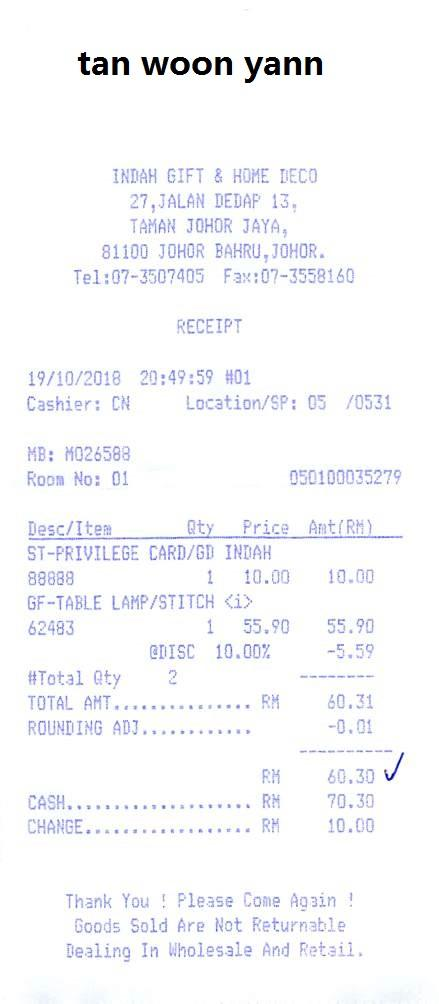

Image size: (439, 1004)


In [59]:
receipt_image = Image.open(receipt_path)
display(receipt_image)
print('Image size:', receipt_image.size)

## Initialize Pipeline

In [60]:
perception = ReceiptPerception()
planner = ReceiptPlanner()
recommender = CreditCardRecommender() if run_control else None

## Helper Functions

In [61]:
def run_pipeline_for_method(image_path, method, run_control=True):
    try:
        ocr_result = perception.extract_text(image_path, method=method)
        spending_profile = planner.build_spending_profile(ocr_result.text)
        recommendation = recommender.recommend_card(spending_profile) if run_control else None
        return {
            'method': method,
            'status': 'ok',
            'error': None,
            'ocr_result': ocr_result,
            'spending_profile': spending_profile,
            'recommendation': recommendation,
        }
    except Exception as exc:
        return {
            'method': method,
            'status': 'error',
            'error': str(exc),
            'ocr_result': None,
            'spending_profile': None,
            'recommendation': None,
        }


def summarize_result(result):
    if result['status'] != 'ok':
        return {
            'method': result['method'],
            'status': 'error',
            'error': result['error'],
            'merchant': None,
            'total_amount': None,
            'line_item_count': None,
            'non_zero_categories': None,
            'primary_card': None,
            'primary_issuer': None,
            'estimated_value': None,
        }

    profile = result['spending_profile']
    recommendation = result['recommendation']
    non_zero_categories = [
        f"{key}: {value:.2f}"
        for key, value in profile.category_totals.items()
        if value > 0
    ]
    return {
        'method': result['method'],
        'status': 'ok',
        'error': None,
        'merchant': profile.merchant,
        'total_amount': profile.total_amount,
        'line_item_count': len(profile.line_items),
        'non_zero_categories': ', '.join(non_zero_categories) if non_zero_categories else '[none]',
        'primary_card': recommendation.primary_card if recommendation else '[skipped]',
        'primary_issuer': recommendation.primary_issuer if recommendation else '[skipped]',
        'estimated_value': recommendation.primary_estimated_value if recommendation else None,
    }


def thumbnail_html(image_path, width=220, max_height=700):
    image = Image.open(image_path).convert('RGB')
    thumbnail = image.copy()
    thumbnail.thumbnail((width, max_height))
    buffer = BytesIO()
    thumbnail.save(buffer, format='JPEG')
    encoded = base64.b64encode(buffer.getvalue()).decode('utf-8')
    return (
        f'<img src="data:image/jpeg;base64,{encoded}" '
        f'style="width:{thumbnail.width}px; border:1px solid #ddd; border-radius:6px;" />'
    )


def parsed_text_html(text, width=420, max_height=320):
    safe_text = html.escape(text or '')
    return (
        f'<div style="width:{width}px; max-height:{max_height}px; overflow:auto; '
        'white-space:pre-wrap; font-family:monospace; font-size:12px; line-height:1.35; '
        'border:1px solid #ddd; border-radius:6px; padding:8px; background:#fafafa;">'
        f'{safe_text}</div>'
    )

## Run All Three Methods on One Receipt

In [62]:
results = [run_pipeline_for_method(receipt_path, method, run_control=run_control) for method in methods]
summary_df = pd.DataFrame([summarize_result(result) for result in results])
display(summary_df)

Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-base-printed and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


,method,status,error,merchant,total_amount,line_item_count,non_zero_categories,primary_card,primary_issuer,estimated_value
0,tesseract,ok,None,tan woon yann,121.57,5,other: 121.57,Blue Cash Preferred,American Express,-0.4
1,trocr,ok,None,ITEM,0.00,0,[none],Blue Cash Preferred,American Express,-95.0
2,labels,ok,None,TAN WOON YANN,131.80,5,other: 131.80,Blue Cash Preferred,American Express,-0.2


## OCR Text Previews

In [63]:
for result in results:
    display(Markdown(f"### {result['method']}"))
    if result['status'] != 'ok':
        print('ERROR:', result['error'])
        print()
        continue

    preview = result['ocr_result'].text[:2000] if result['ocr_result'].text else '[No text extracted]'
    print(preview)
    print()

### tesseract

tan woon yann
INDAK GIFT & HOHE BECO
27, JALAN DELAP 13,
TAMAN JOHOR JAYA,
81100 JOHOR BAHRU, JOHOR.
Tel:G7-3507405 Fax:07-3558160
RECEIPT
19/10/2018 20:49:59 #01
Cashiers CN tocation/SP: 05 /0531
BBs MO26589
Room Noz Of 950100035279
Desc/I tea Qty Price Ant(RH)
ST-FRIVILEGE CARD/GD INDAH
98898 1 10.00 = 10,00
GF-TABLE LAMP/STITCH <i>
62483 1 $5.50 95.90
QMISC 10.00% “5.59
aTotal Qty 2 Sn”
TOTAL ANTscenennecessace RH 40.31
ROUNDING ADTs. seceseeees 0.08
RY 60,30 Jv
CASH eveseverseseesecees RH 70,39
CHANCE esccnsenerensceae RH 10.00
Thank You ! Please Cone Again !
Goods Sold Are Kot Returnable
Pealing In kholesale And Retail,



### trocr

ITEM



### labels

TAN WOON YANN
INDAH GIFT & HOME DECO
27
TAMAN JOHOR JAYA
81100 JOHOR BAHRU
TEL:07-3507405 FAX:07-3558160
RECEIPT
19/10/2018 20:49:59 #01
CASHIER: CN LOCATION/SP: 05 /0531
MB: MO26588
ROOM NO: 01 050100035279
DESC/ITEM QTY PRICE AMT(RM)
ST-PRIVILEGE CARD/GD INDAH
88888 1 10.00 10.00
GF-TABLE LAMP/STITCH <I>
62483 1 55.90 55.90
@DISC 10.00% -5.59
#TOTAL QTY 2
TOTAL AMT................. RM 60.31
ROUNDING ADJ............ -0.01
RM 60.30
CASH.................... RM 70.30
CHANGE.................. RM 10.00
THANK YOU ! FLEASE COME AOSIN ! THANK YOU ! PLEASE COME AGAIN !
GOODS SOLD ARE NOT RETURNABLE GOODS SOLD ARE NOT RETURNABLE
DEALING IN WHOLESALE AND RETAIL.



## Spending Profile Comparison

In [64]:
profiles_df = pd.DataFrame([
    {
        'method': result['method'],
        'status': result['status'],
        'merchant': result['spending_profile'].merchant if result['status'] == 'ok' else None,
        'groceries': result['spending_profile'].category_totals['groceries'] if result['status'] == 'ok' else None,
        'dining': result['spending_profile'].category_totals['dining'] if result['status'] == 'ok' else None,
        'travel': result['spending_profile'].category_totals['travel'] if result['status'] == 'ok' else None,
        'gas': result['spending_profile'].category_totals['gas'] if result['status'] == 'ok' else None,
        'entertainment': result['spending_profile'].category_totals['entertainment'] if result['status'] == 'ok' else None,
        'shopping': result['spending_profile'].category_totals['shopping'] if result['status'] == 'ok' else None,
        'healthcare': result['spending_profile'].category_totals['healthcare'] if result['status'] == 'ok' else None,
        'other': result['spending_profile'].category_totals['other'] if result['status'] == 'ok' else None,
        'total_amount': result['spending_profile'].total_amount if result['status'] == 'ok' else None,
        'line_item_count': len(result['spending_profile'].line_items) if result['status'] == 'ok' else None,
    }
    for result in results
])
display(profiles_df)

,method,status,merchant,groceries,dining,travel,gas,entertainment,shopping,healthcare,other,total_amount,line_item_count
0,tesseract,ok,tan woon yann,0.0,0.0,0.0,0.0,0.0,0.0,0.0,121.57,121.57,5
1,trocr,ok,ITEM,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0
2,labels,ok,TAN WOON YANN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,131.80,131.80,5


## Recommendation Comparison

In [65]:
if run_control:
    recommendations_df = pd.DataFrame([
        {
            'method': result['method'],
            'status': result['status'],
            'primary_card': result['recommendation'].primary_card if result['status'] == 'ok' and result['recommendation'] else None,
            'primary_issuer': result['recommendation'].primary_issuer if result['status'] == 'ok' and result['recommendation'] else None,
            'primary_value': result['recommendation'].primary_estimated_value if result['status'] == 'ok' and result['recommendation'] else None,
            'runner_up_card': result['recommendation'].runner_up_card if result['status'] == 'ok' and result['recommendation'] else None,
            'runner_up_issuer': result['recommendation'].runner_up_issuer if result['status'] == 'ok' and result['recommendation'] else None,
            'runner_up_value': result['recommendation'].runner_up_estimated_value if result['status'] == 'ok' and result['recommendation'] else None,
        }
        for result in results
    ])
    display(recommendations_df)
else:
    print('Control step skipped.')

,method,status,primary_card,primary_issuer,primary_value,runner_up_card,runner_up_issuer,runner_up_value
0,tesseract,ok,Blue Cash Preferred,American Express,-0.4,Citi Custom Cash,Citi,1.22
1,trocr,ok,Blue Cash Preferred,American Express,-95.0,Amex Gold,American Express,-325.00
2,labels,ok,Blue Cash Preferred,American Express,-0.2,Citi Custom Cash,Citi,0.00


## Full Structured Output for One Method

In [66]:
selected_method = 'labels'
selected_result = next(result for result in results if result['method'] == selected_method)

if selected_result['status'] != 'ok':
    print('ERROR:', selected_result['error'])
else:
    combined_output = {
        'ocr': {
            'method': selected_result['ocr_result'].method,
            'image_path': selected_result['ocr_result'].image_path,
            'confidence': selected_result['ocr_result'].confidence,
            'metadata': selected_result['ocr_result'].metadata,
            'text': selected_result['ocr_result'].text,
        },
        'planning': selected_result['spending_profile'].as_dict(),
        'control': selected_result['recommendation'].as_dict() if selected_result['recommendation'] else None,
    }
    print(json.dumps(combined_output, indent=2))

{
  "ocr": {
    "method": "labels",
    "image_path": "/Users/aeshagandhi/Downloads/MIDS-Sp26/Agents/Credit-Card-Agent/data/receipts/X00016469619.jpg",
    "confidence": 1.0,
    "metadata": {
      "source": "SROIE provided words+bboxes",
      "receipt_key": "X00016469619"
    },
    "text": "TAN WOON YANN\nINDAH GIFT & HOME DECO\n27\nTAMAN JOHOR JAYA\n81100 JOHOR BAHRU\nTEL:07-3507405 FAX:07-3558160\nRECEIPT\n19/10/2018 20:49:59 #01\nCASHIER: CN LOCATION/SP: 05 /0531\nMB: MO26588\nROOM NO: 01 050100035279\nDESC/ITEM QTY PRICE AMT(RM)\nST-PRIVILEGE CARD/GD INDAH\n88888 1 10.00 10.00\nGF-TABLE LAMP/STITCH <I>\n62483 1 55.90 55.90\n@DISC 10.00% -5.59\n#TOTAL QTY 2\nTOTAL AMT................. RM 60.31\nROUNDING ADJ............ -0.01\nRM 60.30\nCASH.................... RM 70.30\nCHANGE.................. RM 10.00\nTHANK YOU ! FLEASE COME AOSIN ! THANK YOU ! PLEASE COME AGAIN !\nGOODS SOLD ARE NOT RETURNABLE GOODS SOLD ARE NOT RETURNABLE\nDEALING IN WHOLESALE AND RETAIL."
  },
  "planning

## Batch Comparison Across a Few Receipts

image,receipt,method,parsed_text,status,merchant,total_amount,line_item_count,primary_card,estimated_value,error
,X00016469612.jpg,tesseract,"i og: 8\n2 igki@e zee =\nBREE: fa0 gg =\na F i, 8: : : =\nas ra =\n& fo: Re: t zo\nse ot og: : 22. =\n22 ivf: g'2 &8 8 SS\nLae BE: wR w ek me\nBiggie Ft"" = si =\nZe of IB 25\nworries: Be S —\nan 182: & —\nog ies; : —\nan : Bg: : 2 =\nyt : g: : _——\nDe Si Zt =—\niBioesis ',2\n;O:53 6:8 ;s2°",ok,i og: 8,0.00,0,Blue Cash Preferred,-95.00,None
,X00016469612.jpg,trocr,CASHIER,ok,CASHIER,0.00,0,Blue Cash Preferred,-95.00,None
,X00016469612.jpg,labels,TAN WOON YANN\nBOOK TA .K(TAMAN DAYA) SDN BND\n789417-W\nNO.53 55\nTAMAN DAYA\n81100 JOHOR BAHRU\nJOHOR.\nDOCUMENT NO : TD01167104\nDATE: 25/12/2018 8:13:39 PM\nCASHIER: MANIS\nMEMBER:\nCASH BILL\nCODE/DESC PRICE DISC AMOUNT\nQTY RM RM\n9556939040116 KF MODELLING CLAY KIDDY FISH\n1 PC * 9.000 0.00 9.00\nTOTAL: 9.00\nROUR DING ADJUSTMENT: 0.00\nROUND D TOTAL (RM): 9.00\nCASH 10.00\nCHANGE 1.00\nGOODS SOLD ARE NOT RETURNABLE OR\nEXCHANGEABLE\n***\n***\nTHANK YOU\nPLEASE COME AGAIN !,ok,TAN WOON YANN,9.00,2,Blue Cash Preferred,-86.00,None
,X00016469619.jpg,tesseract,"tan woon yann\nINDAK GIFT & HOHE BECO\n27, JALAN DELAP 13,\nTAMAN JOHOR JAYA,\n81100 JOHOR BAHRU, JOHOR.\nTel:G7-3507405 Fax:07-3558160\nRECEIPT\n19/10/2018 20:49:59 #01\nCashiers CN tocation/SP: 05 /0531\nBBs MO26589\nRoom Noz Of 950100035279\nDesc/I tea Qty Price Ant(RH)\nST-FRIVILEGE CARD/GD INDAH\n98898 1 10.00 = 10,00\nGF-TABLE LAMP/STITCH <i>\n62483 1 $5.50 95.90\nQMISC 10.00% “5.59\naTotal Qty 2 Sn”\nTOTAL ANTscenennecessace RH 40.31\nROUNDING ADTs. seceseeees 0.08\nRY 60,30 Jv\nCASH eveseverseseesecees RH 70,39\nCHANCE esccnsenerensceae RH 10.00\nThank You ! Please Cone Again !\nGoods Sold Are Kot Returnable\nPealing In kholesale And Retail,",ok,tan woon yann,121.57,5,Blue Cash Preferred,-0.40,None
,X00016469619.jpg,trocr,ITEM,ok,ITEM,0.00,0,Blue Cash Preferred,-95.00,None
,X00016469619.jpg,labels,TAN WOON YANN\nINDAH GIFT & HOME DECO\n27\nTAMAN JOHOR JAYA\n81100 JOHOR BAHRU\nTEL:07-3507405 FAX:07-3558160\nRECEIPT\n19/10/2018 20:49:59 #01\nCASHIER: CN LOCATION/SP: 05 /0531\nMB: MO26588\nROOM NO: 01 050100035279\nDESC/ITEM QTY PRICE AMT(RM)\nST-PRIVILEGE CARD/GD INDAH\n88888 1 10.00 10.00\nGF-TABLE LAMP/STITCH <I>\n62483 1 55.90 55.90\n@DISC 10.00% -5.59\n#TOTAL QTY 2\nTOTAL AMT................. RM 60.31\nROUNDING ADJ............ -0.01\nRM 60.30\nCASH.................... RM 70.30\nCHANGE.................. RM 10.00\nTHANK YOU ! FLEASE COME AOSIN ! THANK YOU ! PLEASE COME AGAIN !\nGOODS SOLD ARE NOT RETURNABLE GOODS SOLD ARE NOT RETURNABLE\nDEALING IN WHOLESALE AND RETAIL.,ok,TAN WOON YANN,131.80,5,Blue Cash Preferred,-0.20,None
,X00016469620.jpg,tesseract,"LD4ie QuBezzTOTKH Ome}\nBai BUSRSSsornanz!\nPSO S ST BAL kSSB4AsS}\ntSS18 FSVVSESSO L933}\nPSE} 2 BSSPStSeteszrt :\nSH 1g 2*8ala4eesort ~~\nse IS BESS aS) Mess 3:\nge B' Str SPr Grass 2:\n2 {6 thomoet= (2 ‘ Si\nE> t Sers's .=2 +2: =2°\nES tm BV aNnen SS LS! Sar\nn= ot 2 SBaEEl TH pEs 8\nSa 3 & 2a7S Set Es\nBs E27 => » ~S! oF\nSoi > -m 8 ; S65\n=z 3 = S Bb etx,\nmt r=9 FE Stata\ni S a & Fiznw\n‘ 2 2 8 &Isms\na\t mh Bb xt1Ssee\n: o -& S1ase\n~ \i 2 2. ww, F902\nH uo fe Boe R= Sim le\nH S- & ‘ wt Tas\ni\n5 «x Bx xe ox St BF\nH a S* Si Be\n> A Bo se 1 8\n: wo o Swe Tse et 2\nt : ge ere Le St em\nt & ee =o =e St Es\n‘so &$ S ""RB =O Ef =\nis z st =\narmis we ‘ Fs\neae fe. i S\nZig wo wo 2 2 t E-\norate : : bs H\nBoot > |e 8s 8 :\nGO%1, 2B SS BF F&F 1\ntoo | ‘\nSSN ia :",ok,LD4ie QuBezzTOTKH Ome},0.00,0,Blue Cash Preferred,-95.00,None
,X00016469620.jpg,trocr,***,ok,***,0.00,0,Blue Cash Preferred,-95.00,None
,X00016469620.jpg,labels,TAN WOON YANN\nMR D.T.Y. (JOHOR) SDN BHD\n(CO.REG : 933109-X)\nLOT 1851-A & 1851-B\nKAWASAN PERINDUSTRIAN BALAKONG\n43300 SERI KEMBANGAN\n(MR DIY TESCO TERBAU)\n-INVOICE-\nCHOPPING BOARD 35.5X25.5CM 803M#\nEZ10HD05 - 24\n8970669 1 X 19.00 19.00\nAIR PRESSURE SPRAYER SX-575-1 1.5L\nHC03-7 - 15\n9066468 1 X 8
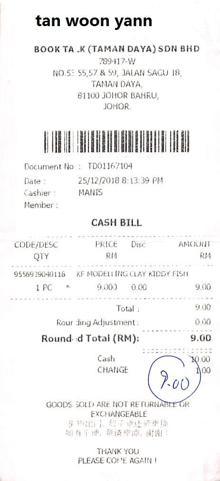
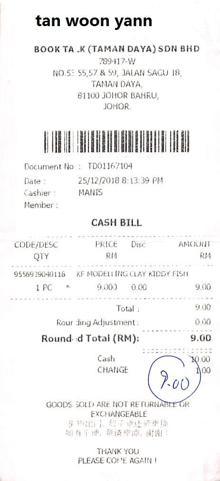
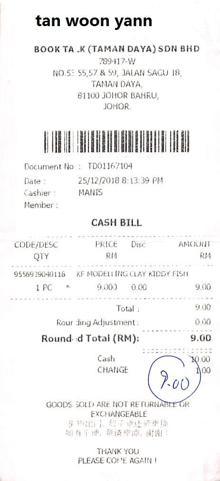
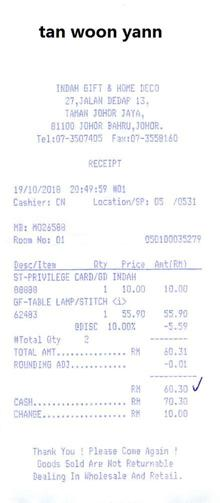
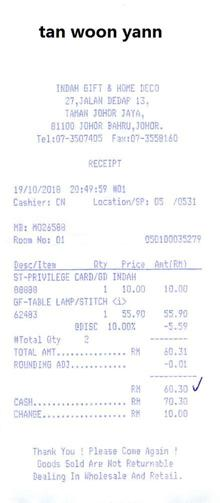
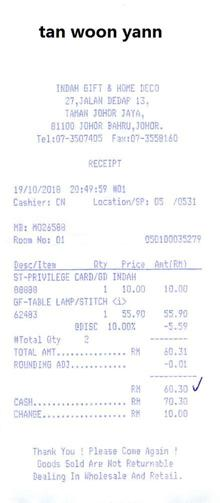
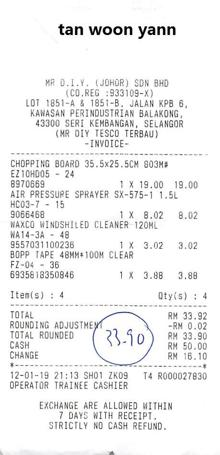
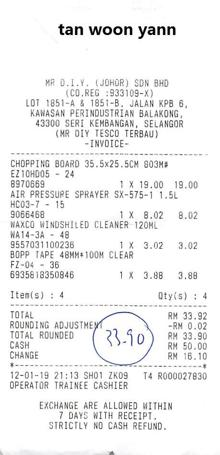
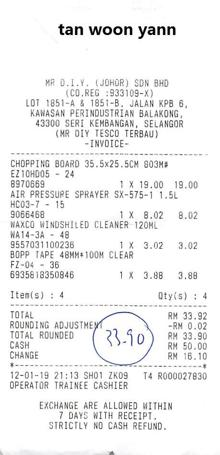

In [67]:
sample_receipts = sorted((PROJECT_ROOT / "data" / "receipts").glob("*.jpg"))[:3]
batch_rows = []

for image_path in sample_receipts:
    for method in methods:
        result = run_pipeline_for_method(image_path, method, run_control=run_control)
        batch_rows.append({
            "image": thumbnail_html(image_path),
            "receipt": image_path.name,
            "method": method,
            "parsed_text": parsed_text_html(result["ocr_result"].text) if result["status"] == "ok" else None,
            "status": result["status"],
            "merchant": result["spending_profile"].merchant if result["status"] == "ok" else None,
            "total_amount": result["spending_profile"].total_amount if result["status"] == "ok" else None,
            "line_item_count": len(result["spending_profile"].line_items) if result["status"] == "ok" else None,
            "primary_card": result["recommendation"].primary_card if result["status"] == "ok" and result["recommendation"] else None,
            "estimated_value": result["recommendation"].primary_estimated_value if result["status"] == "ok" and result["recommendation"] else None,
            "error": result["error"],
        })

batch_df = pd.DataFrame(batch_rows, columns=[
    "image",
    "receipt",
    "method",
    "parsed_text",
    "status",
    "merchant",
    "total_amount",
    "line_item_count",
    "primary_card",
    "estimated_value",
    "error",
])

table_html = batch_df.to_html(escape=False, index=False)
table_html = table_html.replace(
    '<table border="1" class="dataframe">',
    '<table border="1" class="dataframe comparison-table">'
)

display(HTML('''
<style>
.comparison-table td, .comparison-table th {
    vertical-align: top;
    text-align: left;
    padding: 8px;
}
</style>
''' + table_html))
